##### Load the dataset

In [2]:
import pandas as pd

df = pd.read_csv("../data/creditcard.csv")

print("Dataset shape:", df.shape)

Dataset shape: (284807, 31)


##### Seperate Features and target

Here:    
X = Time, V1–V28, Amount   
y = Class

In [3]:
X = df.drop(columns="Class")
y = df["Class"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (284807, 30)
Target shape: (284807,)


##### Create Train / Validation / Test sets

In [4]:
from sklearn.model_selection import train_test_split

##### First seperate the final test set:

In [5]:
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

##### Now split the remaining 80% into training and validation:

In [6]:
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, stratify=y_train_val, random_state=42)

80% remaining × 25% = 20% of full dataset    
Training   = 60%     
Validation = 20%    
Test       = 20%

In [7]:
print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (170883, 30)
Validation set: (56962, 30)
Test set: (56962, 30)


In [9]:
print("\n Fraud percentage:")

print(f"Train:      {y_train.mean() * 100:.4f}%")
print(f"Validation: {y_val.mean() * 100:.4f}%")
print(f"Test:       {y_test.mean() * 100:.4f}%")

# Because we used stratify=y, all three should remain close to the original dataset's fraud percentage, which is around 0.1727%.


 Fraud percentage:
Train:      0.1726%
Validation: 0.1738%
Test:       0.1720%


In [10]:
train_features = X_train.copy()

train_features[["Time", "Amount"]].describe()

,Time,Amount
count,170883.000000,170883.000000
mean,94864.790582,87.631740
std,47459.218514,243.801162
min,0.000000,0.000000
25%,54229.000000,5.580000
50%,84793.000000,22.000000
75%,139295.500000,77.050000
max,172788.000000,19656.530000


V1–V28 are already PCA-transformed features, while Time and Amount are still on their original scales. We want to see whether Amount is heavily skewed and decide how to preprocess it.     
Important: we are checking this on X_train only, not the full dataset. That keeps our methodology clean.

In [11]:
print("Time skewness:", X_train["Time"].skew())
print("Amount skewness:", X_train["Amount"].skew())

Time skewness: -0.037732560780754494
Amount skewness: 15.620488164735095


Time skewness = -0.038 → almost symmetric, so no transformation is needed.    
Amount skewness = 15.62 → extremely right-skewed, so we should investigate a transformation before modeling.

scaling does not fix skewness. StandardScaler or RobustScaler changes the scale, but a heavily right-skewed distribution remains skewed

In [12]:
import numpy as np

log_amount = np.log1p(X_train["Amount"])

print("Originl Amount skewness:", X_train["Amount"].skew())
print("Log-transformed Amount skewness:", log_amount.skew())

Originl Amount skewness: 15.620488164735095
Log-transformed Amount skewness: 0.15698594769302707


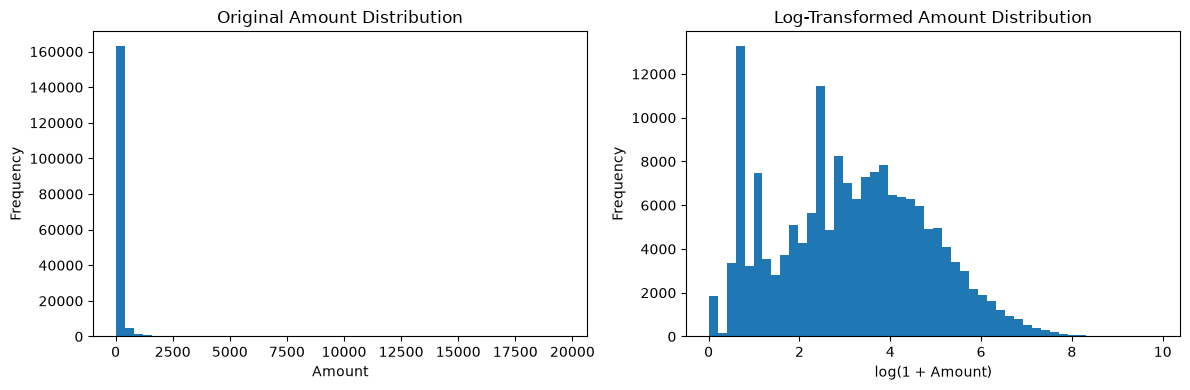

In [14]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(X_train["Amount"], bins=50)
axes[0].set_title("Original Amount Distribution")
axes[0].set_xlabel("Amount")
axes[0].set_ylabel("Frequency")

axes[1].hist(log_amount, bins=50)
axes[1].set_title("Log-Transformed Amount Distribution")
axes[1].set_xlabel("log(1 + Amount)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import PowerTransformer

power_transformer = PowerTransformer(method='yeo-johnson')

power_transformed_amount = power_transformer.fit_transform(X_train[["Amount"]]).ravel()

print("Original Amount skewness:", X_train["Amount"].skew())

print("Log-transformed Amount skewness:", log_amount.skew())

print("Power transformed Amount skewness:", pd.Series(power_transformed_amount).skew())

Original Amount skewness: 15.620488164735095
Log-transformed Amount skewness: 0.15698594769302707
Power transformed Amount skewness: 0.017812056212019114


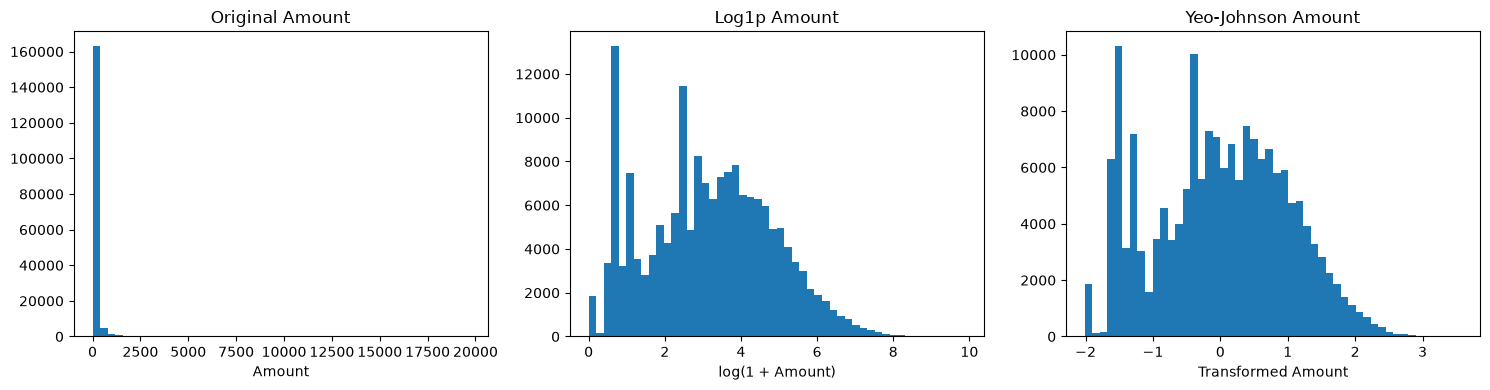

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(X_train["Amount"], bins=50)
axes[0].set_title("Original Amount")
axes[0].set_xlabel("Amount")

axes[1].hist(log_amount, bins=50)
axes[1].set_title("Log1p Amount")
axes[1].set_xlabel("log(1 + Amount)")

axes[2].hist(power_transformed_amount, bins=50)
axes[2].set_title("Yeo-Johnson Amount")
axes[2].set_xlabel("Transformed Amount")

plt.tight_layout()
plt.show()

Both Log1p and Yeo–Johnson substantially reduce the skewness of the Amount feature. Yeo–Johnson produces a more symmetric distribution, but the final transformation will be selected based on model performance during cross-validation rather than skewness alone.

### Preprocessing Summary

- The dataset was split into training, validation, and test sets using stratification.
- The test set will remain untouched until final evaluation.
- The `Time` feature showed almost no skewness, so no transformation is needed.
- The `Amount` feature was highly right-skewed.
- `log1p` reduced the skewness substantially.
- Yeo-Johnson reduced the skewness even further.
- The final transformation will be selected later based on cross-validation performance, not skewness alone.